# Baseline

## Configuración

In [1]:
import warnings, os, json
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              HistGradientBoostingClassifier)
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, precision_recall_curve,
                             roc_curve, auc)
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

# 11 modelos ordenados por familia: distancia -> lineal -> kernel -> red -> arboles -> boosting -> cascada
MODEL_COLORS = {
    'KNN':                  'blue',
    'Reg. Logística':       'orange',
    'SVM (RBF)':            'teal',
    'MLP':                  'magenta',
    'Árbol de Decisión':    'green',
    'Random Forest':        'red',
    'ExtraTrees':           'olive',
    'HistGradientBoosting': 'brown',
    'XGBoost':              'purple',
    'LightGBM':             'darkcyan',
    'CatBoost':             'goldenrod',
}
MODELOS = list(MODEL_COLORS.keys())

df = pd.read_csv('../data/processed/data_procesada.csv')
EXCLUIR = ['Au_ppm', 'target_Au', 'East', 'North', 'Level']
FEATURES = [c for c in df.columns if c not in EXCLUIR]
X = df[FEATURES].copy()
y = df['target_Au'].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

os.makedirs('outputs_sprint0', exist_ok=True)
print(f'Modelos en competencia: {len(MODELOS)}')
print(f'Features: {len(FEATURES)} (sin Au, sin coordenadas)')
print(f'Train: {X_train.shape} dist={y_train.value_counts().to_dict()}')
print(f'Test : {X_test.shape} dist={y_test.value_counts().to_dict()}')

Modelos en competencia: 11
Features: 46 (sin Au, sin coordenadas)
Train: (1705, 46) dist={0: 1497, 1: 208}
Test : (427, 46) dist={0: 375, 1: 52}


## Funciones

In [2]:
def crear_modelos():
    """11 modelos con configuracion por defecto/ligera, ordenados por familia.
    Todos dentro de un Pipeline con StandardScaler (inofensivo para arboles,
    necesario para KNN/LogReg/SVM/MLP). El escalado se ajusta SOLO en train."""
    modelos = {
        # --- basados en distancia / lineal / kernel / red neuronal ---
        'KNN':                  Pipeline([('sc', StandardScaler()),
                                          ('clf', KNeighborsClassifier(n_neighbors=5))]),
        'Reg. Logística':       Pipeline([('sc', StandardScaler()),
                                          ('clf', LogisticRegression(max_iter=1000, random_state=SEED))]),
        'SVM (RBF)':            Pipeline([('sc', StandardScaler()),
                                          ('clf', SVC(kernel='rbf', random_state=SEED))]),
        'MLP':                  Pipeline([('sc', StandardScaler()),
                                          ('clf', MLPClassifier(hidden_layer_sizes=(100,), max_iter=500,
                                                                random_state=SEED))]),
        # --- arboles y ensambles bagging ---
        'Árbol de Decisión':    Pipeline([('sc', StandardScaler()),
                                          ('clf', DecisionTreeClassifier(random_state=SEED))]),
        'Random Forest':        Pipeline([('sc', StandardScaler()),
                                          ('clf', RandomForestClassifier(n_estimators=100, random_state=SEED,
                                                                         n_jobs=-1))]),
        'ExtraTrees':           Pipeline([('sc', StandardScaler()),
                                          ('clf', ExtraTreesClassifier(n_estimators=100, random_state=SEED,
                                                                       n_jobs=-1))]),
        # --- ensambles boosting ---
        'HistGradientBoosting': Pipeline([('sc', StandardScaler()),
                                          ('clf', HistGradientBoostingClassifier(random_state=SEED))]),
        'XGBoost':              Pipeline([('sc', StandardScaler()),
                                          ('clf', xgb.XGBClassifier(n_estimators=100, random_state=SEED,
                                                                    eval_metric='logloss',
                                                                    tree_method='hist', n_jobs=-1))]),
        'LightGBM':             Pipeline([('sc', StandardScaler()),
                                          ('clf', lgb.LGBMClassifier(n_estimators=100, random_state=SEED,
                                                                     verbose=-1, n_jobs=-1))]),
        'CatBoost':             Pipeline([('sc', StandardScaler()),
                                          ('clf', CatBoostClassifier(iterations=100, random_seed=SEED,
                                                                     verbose=0, allow_writing_files=False))]),
    }
    return modelos

def scores_pos(modelo, Xte):
    """Probabilidad/score de la clase positiva (decision_function si no hay predict_proba)."""
    clf = modelo.named_steps['clf'] if hasattr(modelo, 'named_steps') else modelo
    if hasattr(clf, 'predict_proba'):
        return modelo.predict_proba(Xte)[:, 1]
    return modelo.decision_function(Xte)

def metricas(yte, y_pred, y_sco):
    return {
        'F1':        f1_score(yte, y_pred),
        'Accuracy':  accuracy_score(yte, y_pred),
        'Precision': precision_score(yte, y_pred, zero_division=0),
        'Recall':    recall_score(yte, y_pred),
        'AUC-ROC':   roc_auc_score(yte, y_sco),
    }

def evaluar_pipeline(modelo, Xtr, ytr, Xte, yte):
    modelo.fit(Xtr, ytr)
    y_pred = modelo.predict(Xte); y_sco = scores_pos(modelo, Xte)
    m = metricas(yte, y_pred, y_sco); m['_pred'] = y_pred; m['_score'] = y_sco
    return m
print('Funciones listas')

Funciones listas


## Modelos Baseline

In [3]:
import time
res_f0, tiempos = {}, {}
for n, m in crear_modelos().items():
    t0 = time.time()
    res_f0[n] = evaluar_pipeline(m, X_train, y_train, X_test, y_test)
    tiempos[n] = time.time() - t0
    print(f'  {n}: F1={res_f0[n]["F1"]:.4f} ({tiempos[n]:.1f}s)')

tabla_f0 = pd.DataFrame({m: {k: res_f0[m][k] for k in ['F1','Accuracy','Precision','Recall','AUC-ROC']}
                         for m in MODELOS}).T[['F1','Accuracy','Precision','Recall','AUC-ROC']].round(4)
tabla_f0['Tiempo (s)'] = pd.Series(tiempos).round(1)
tabla_f0.to_csv('outputs_sprint0/baseline_metricas.csv')

def resaltar_maximo(s):
    estilos = [''] * len(s)
    idx_max = s.idxmax()
    estilos[s.index.get_loc(idx_max)] = 'background-color: coral; color: white; font-weight: bold'
    return estilos

print('\nMétricas en HOLD-OUT')
tabla_f0.style.apply(resaltar_maximo, axis=0, subset=['F1','Accuracy','Precision','Recall','AUC-ROC'])\
        .format('{:.4f}', subset=['F1','Accuracy','Precision','Recall','AUC-ROC'])\
        .format('{:.1f}', subset=['Tiempo (s)'])

  KNN: F1=0.3243 (0.4s)
  Reg. Logística: F1=0.6118 (0.2s)
  SVM (RBF): F1=0.2333 (0.3s)
  MLP: F1=0.7551 (4.5s)
  Árbol de Decisión: F1=0.6393 (0.1s)
  Random Forest: F1=0.6437 (0.5s)
  ExtraTrees: F1=0.5750 (0.3s)
  HistGradientBoosting: F1=0.7447 (0.5s)
  XGBoost: F1=0.7629 (0.3s)
  LightGBM: F1=0.7216 (0.3s)
  CatBoost: F1=0.7010 (0.8s)

Métricas en HOLD-OUT


,F1,Accuracy,Precision,Recall,AUC-ROC,Tiempo (s)
KNN,0.3243,0.8829,0.5455,0.2308,0.8390,0.4
Reg. Logística,0.6118,0.9227,0.7879,0.5000,0.9369,0.2
SVM (RBF),0.2333,0.8923,0.8750,0.1346,0.9122,0.3
MLP,0.7551,0.9438,0.8043,0.7115,0.9395,4.5
Árbol de Decisión,0.6393,0.8970,0.5571,0.7500,0.8337,0.1
Random Forest,0.6437,0.9274,0.8000,0.5385,0.9547,0.5
ExtraTrees,0.5750,0.9204,0.8214,0.4423,0.9469,0.3
HistGradientBoosting,0.7447,0.9438,0.8333,0.6731,0.9674,0.5
XGBoost,0.7629,0.9461,0.8222,0.7115,0.9648,0.3
LightGBM,0.7216,0.9368,0.7778,0.6731,0.9668,0.3


## Gráfico comparativo

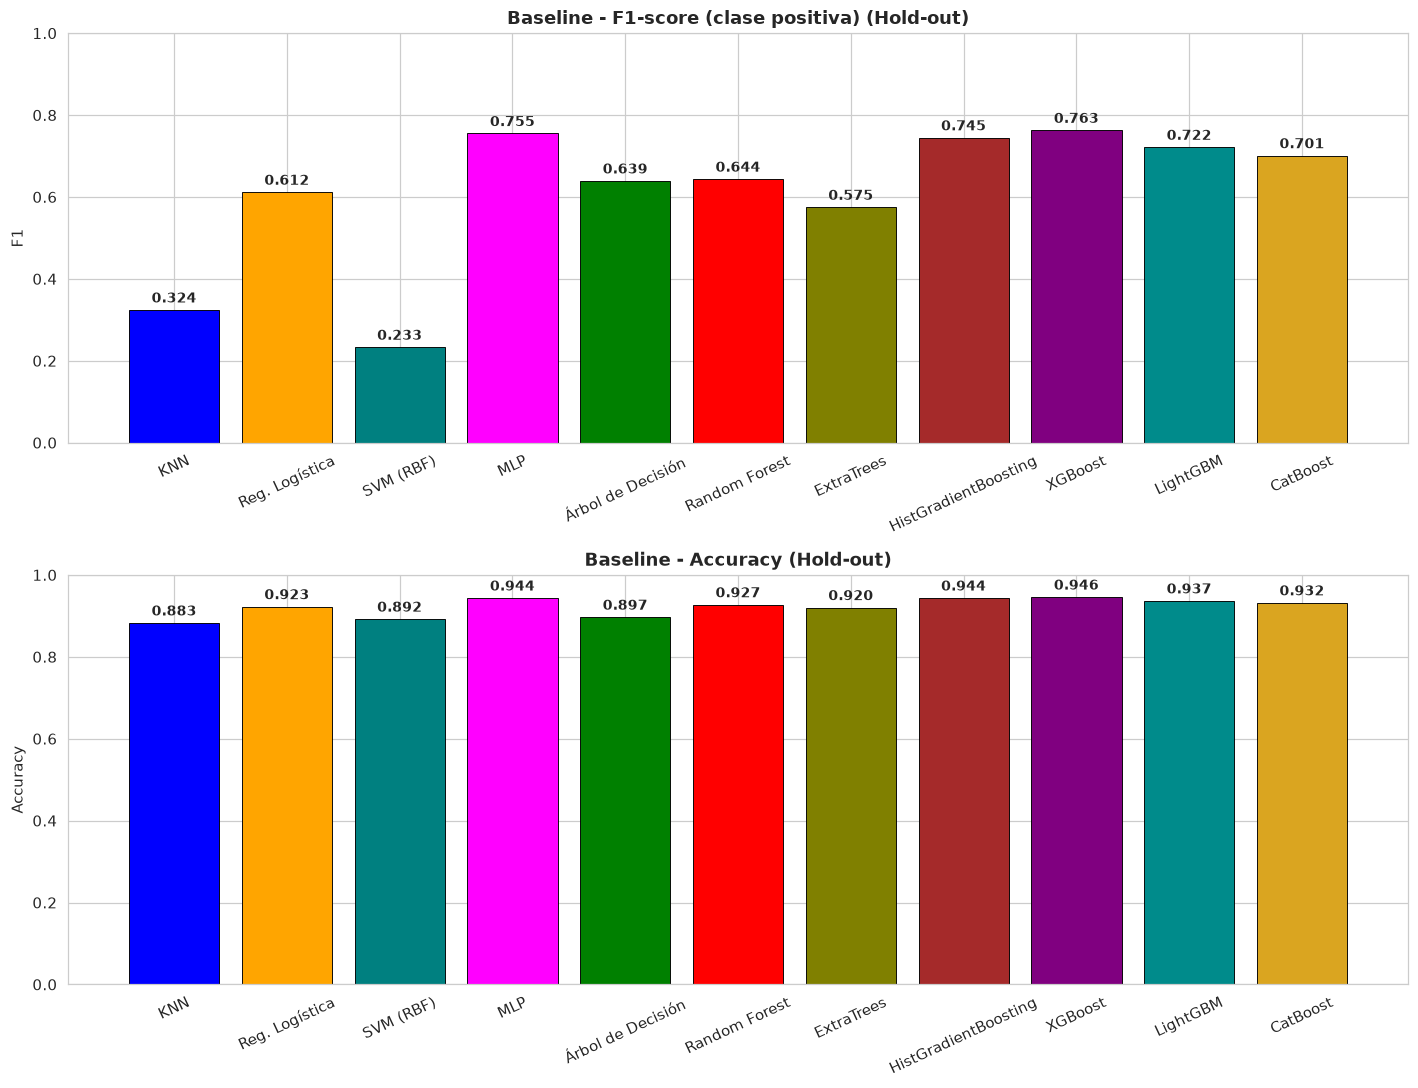

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 10))
colores = [MODEL_COLORS[m] for m in tabla_f0.index]
for ax, col, tit in zip(axes, ['F1','Accuracy'], ['F1-score (clase positiva)','Accuracy']):
    b = ax.bar(tabla_f0.index, tabla_f0[col], color=colores, edgecolor='black', linewidth=.6)
    ax.set_title(f'Baseline - {tit} (Hold-out)', fontweight='bold')
    ax.set_ylabel(col); ax.set_ylim(0, 1); ax.tick_params(axis='x', rotation=25)
    for r in b: ax.text(r.get_x()+r.get_width()/2, r.get_height()+.01, f'{r.get_height():.3f}',
                        ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout(); plt.savefig('outputs_sprint0/baseline_barras.png', bbox_inches='tight'); plt.show()

## Matriz de confusión

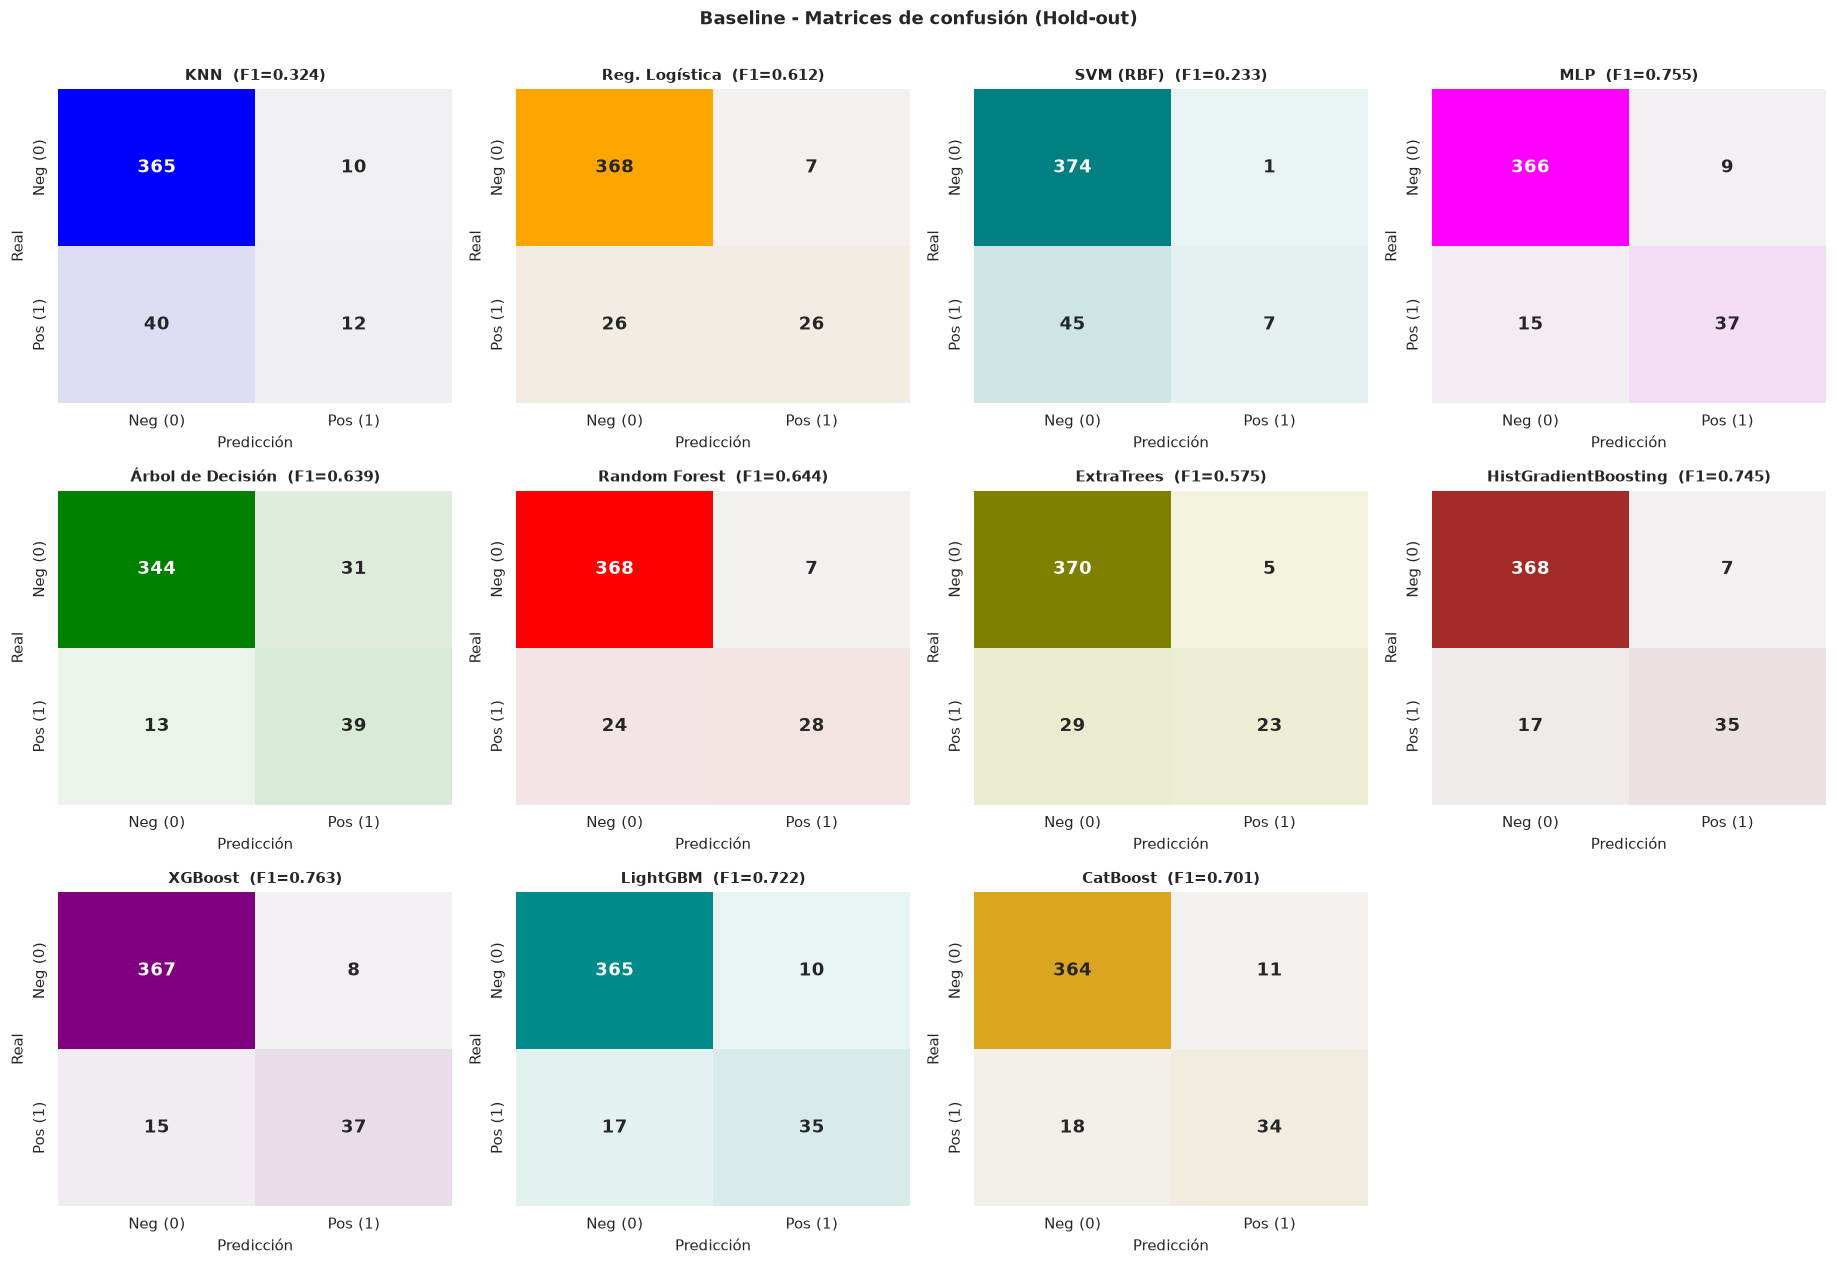

In [5]:
n_mod = len(MODELOS)
n_cols = 4
n_rows = int(np.ceil(n_mod / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2*n_cols, 3.8*n_rows))
axes = np.atleast_2d(axes)
for ax, nombre in zip(axes.ravel(), MODELOS):
    cm = confusion_matrix(y_test, res_f0[nombre]['_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=ax,
                cmap=sns.light_palette(MODEL_COLORS[nombre], as_cmap=True),
                xticklabels=['Neg (0)','Pos (1)'], yticklabels=['Neg (0)','Pos (1)'],
                annot_kws={'size':12,'fontweight':'bold'})
    ax.set_title(f'{nombre}  (F1={res_f0[nombre]["F1"]:.3f})', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
for ax in axes.ravel()[n_mod:]:
    ax.axis('off')
plt.suptitle('Baseline - Matrices de confusión (Hold-out)', fontweight='bold', y=1.005)
plt.tight_layout(); plt.savefig('outputs_sprint0/baseline_matrices_confusion.png', bbox_inches='tight'); plt.show()

## Curva Precisión-Recall y Curva ROC

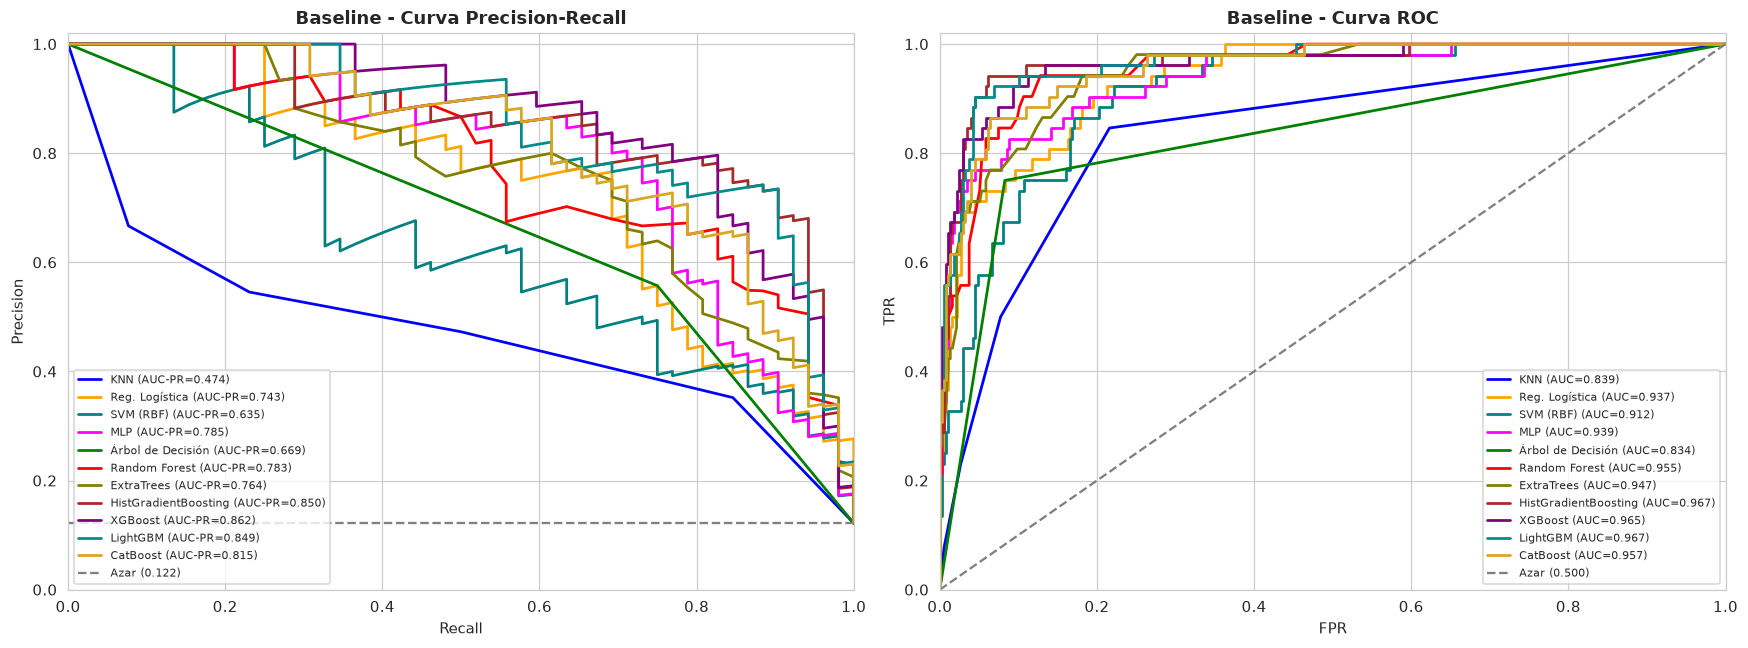

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for nombre in MODELOS:
    p, r, _ = precision_recall_curve(y_test, res_f0[nombre]['_score'])
    axes[0].plot(r, p, color=MODEL_COLORS[nombre], lw=1.8, label=f'{nombre} (AUC-PR={auc(r,p):.3f})')
axes[0].hlines(y_test.mean(), 0, 1, colors='gray', linestyles='--', label=f'Azar ({y_test.mean():.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision'); axes[0].set_xlim(0,1); axes[0].set_ylim(0,1.02)
axes[0].set_title('Baseline - Curva Precision-Recall', fontweight='bold'); axes[0].legend(fontsize=7.5)
for nombre in MODELOS:
    fpr, tpr, _ = roc_curve(y_test, res_f0[nombre]['_score'])
    axes[1].plot(fpr, tpr, color=MODEL_COLORS[nombre], lw=1.8, label=f'{nombre} (AUC={res_f0[nombre]["AUC-ROC"]:.3f})')
axes[1].plot([0,1],[0,1],'--',color='gray', label='Azar (0.500)')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].set_xlim(0,1); axes[1].set_ylim(0,1.02)
axes[1].set_title('Baseline - Curva ROC', fontweight='bold'); axes[1].legend(fontsize=7.5, loc='lower right')
plt.tight_layout(); plt.savefig('outputs_sprint0/baseline_curvas_pr_roc.png', bbox_inches='tight'); plt.show()

## Resumen

In [7]:
mejor_modelo = tabla_f0['F1'].idxmax()
res_mejor = res_f0[mejor_modelo]
METRICAS = ['F1','Accuracy','Precision','Recall','AUC-ROC']

resumen0 = {'mejor_modelo': mejor_modelo,
            'f1_final': round(float(res_mejor['F1']), 4),
            'metricas_finales': {m: round(float(res_mejor[m]), 4) for m in METRICAS},
            'f1_por_modelo': {m: round(float(res_f0[m]['F1']), 4) for m in MODELOS},
            'n_modelos': len(MODELOS),
            'n_features': len(FEATURES)}
with open('outputs_sprint0/resumen_sprint0.json', 'w') as f:
    json.dump(resumen0, f, indent=2, ensure_ascii=False)

print('════════════ RESUMEN SPRINT 0 ════════════')
print(f'Competencia baseline de {len(MODELOS)} modelos (sin balanceo, sin PCA, sin tuning)')
print('\nRanking por F1 (hold-out):')
for i, (mod, f1) in enumerate(tabla_f0['F1'].sort_values(ascending=False).items(), 1):
    marca = ' ← GANADOR' if mod == mejor_modelo else ''
    print(f'  {i:2d}. {mod}: F1 = {f1:.4f}{marca}')
print(f'\nMejor modelo baseline: {mejor_modelo} → F1 = {res_mejor["F1"]:.4f}')
print('Métricas del ganador:', {m: round(res_mejor[m], 4) for m in METRICAS})
print('\nSiguiente paso (Sprint 1): balanceo de clases y PCA con los 11 modelos.')

════════════ RESUMEN SPRINT 0 ════════════
Competencia baseline de 11 modelos (sin balanceo, sin PCA, sin tuning)

Ranking por F1 (hold-out):
   1. XGBoost: F1 = 0.7629 ← GANADOR
   2. MLP: F1 = 0.7551
   3. HistGradientBoosting: F1 = 0.7447
   4. LightGBM: F1 = 0.7216
   5. CatBoost: F1 = 0.7010
   6. Random Forest: F1 = 0.6437
   7. Árbol de Decisión: F1 = 0.6393
   8. Reg. Logística: F1 = 0.6118
   9. ExtraTrees: F1 = 0.5750
  10. KNN: F1 = 0.3243
  11. SVM (RBF): F1 = 0.2333

Mejor modelo baseline: XGBoost → F1 = 0.7629
Métricas del ganador: {'F1': 0.7629, 'Accuracy': 0.9461, 'Precision': 0.8222, 'Recall': 0.7115, 'AUC-ROC': 0.9648}

Siguiente paso (Sprint 1): balanceo de clases y PCA con los 11 modelos.
